In [ ]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from scipy.stats import gaussian_kde, kendalltau, pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict

from helper import *

use_paper_style()
%load_ext autoreload
%autoreload 2

In [ ]:
# Load free energies and ranking, ligand and pocket features
data = load_ligand_data()
pocket_features = load_pocket_features(cutoff=6.0)
data = data.merge(pocket_features, how="left", on=["system", "target"])
ranking_data = ranking_features()
lig = load_ligand_features()

In [ ]:
# Load or compute bonded distribution scores for the ligand features
dist_score_path = Path('bonded-distribution-scores.json')
if not dist_score_path.exists():
    bonded_scores = score_bonded_distributions()
    with open(dist_score_path, 'w') as f:
        json.dump(bonded_scores, f, indent=2)
else:
    with open(dist_score_path, 'r') as f:
        bonded_scores = json.load(f)

Correlate rho and offset: 0.23705674487372172
MAE: 5.034
Min and max offsets: ('t4lys', -2.7204608349421755) ('eg5', -8.667891232968305)
Min and max Spearman rhos: ('mup1', 0.8857142857142858) ('cmet', -0.4055944055944056)
Mean dynamic range: 4.411333402293946
Median dynamic range: 3.630000114440918


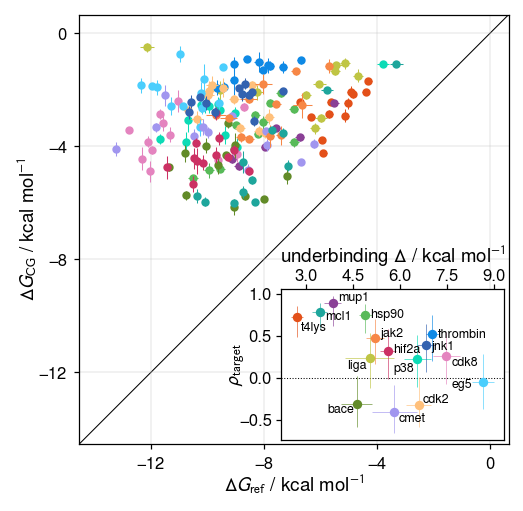

In [7]:
offsets = {}
spearman_rhos = {}
fig, axs = figure("single", height=3.3, ncols=1)
extra_legend_handles = []
for i, (name, target_data) in enumerate(iterate_targets(data)):
    hdl = axs.errorbar(target_data["fep"], target_data["dG"], yerr=target_data["ddG"],
        xerr=target_data["fep-err"], fmt="o", markersize=3, lw=0.5, zorder=20 - i)
# Setup axis
axs.set_xlabel(r"$\Delta G_{\mathrm{ref}}$ / kcal mol$^{-1}$", labelpad=0)
axs.set_ylabel(r"$\Delta G_{\mathrm{CG}}$ / kcal mol$^{-1}$", labelpad=0)
square_with_diagonal(axs, pad=0.05, nticks=5)
axs.grid(alpha=0.2)
# Create inset
iax = axs.inset_axes([0.47, 0.01, 0.52, 0.35])
offsets = {}
dyn_ranges = {}
for i, (name, target_data) in enumerate(iterate_targets(data)):
    offset = (target_data["fep"] - target_data["dG"]).mean()
    offsets[name] = float(offset)
    offset_se = (target_data["fep"] - target_data["dG"]).std() / np.sqrt(len(target_data))
    rho = spearmanr(target_data["fep"], target_data["dG"]).statistic
    spearman_rhos[name] = float(rho)
    rho_le, rho_he = spearman_se(rho, len(target_data))
    dyn_ranges[name] = target_data["fep"].max() - target_data["fep"].min()
    iax.errorbar(-offset, rho, yerr=[[rho - rho_le], [rho_he - rho]], xerr=offset_se, fmt="o", label=name, zorder=20 - i, lw=0.3)
    xydict = {'mcl1': (2.5, -2.5), 'mup1': (2.5, 2.8), 'cmet': (2.3, -3), 'eg5': (-15, -1.4), 'cdk8': (2.5, -3.0),
        'jak2': (2.5, 2), 'p38': (-11.5, -4.5), 'liga': (-11, -3.5), 'jnk1': (2.5, -1.0), 'cdk2': (2.0, 2.5),
        't4lys': (1.5, -5), 'hif2a': (2.5, 1.0), 'hsp90': (2.5, 0.0), 'bace': (-14, -2.5), 'thrombin': (2.5, 0.0)}
    iax.annotate(name, xy=(-offset, rho), xytext=xydict[name], textcoords="offset points", ha="left", va="center", fontsize=6, zorder=30)
iax.set_xlabel(r"underbinding $\Delta$ / kcal mol$^{-1}$", labelpad=3)
iax.xaxis.set_label_position("top")
iax.set_ylabel(r"$\rho_{\mathrm{target}}$", labelpad=-4)
iax.axhline(0, color="black", ls=":", lw=0.5, zorder=0)
iax.xaxis.set_ticks_position("top")
iax.tick_params(axis="y", which="major", pad=2)
iax.tick_params(axis="x", which="major", pad=0)
iax.xaxis.set_major_locator(MaxNLocator(nbins=5))
# Print info
R2_offset_rho = pearsonr(-np.array(list(offsets.values())), np.array(list(spearman_rhos.values()))).statistic**2
print("Correlate rho and offset:", R2_offset_rho)
mae = np.abs(target_data["fep"] - target_data["dG"]).mean()
print(f"MAE: {mae:.3f}")
offsets = sorted(offsets.items(), key=lambda x: x[1], reverse=True)
print('Min and max offsets:', offsets[0], offsets[-1])
spearman_rhos = sorted(spearman_rhos.items(), key=lambda x: x[1], reverse=True)
print('Min and max Spearman rhos:', spearman_rhos[0], spearman_rhos[-1])
mean_dyn_range = np.mean(list(dyn_ranges.values()))
print('Mean dynamic range:', mean_dyn_range)
median_dyn_range = np.median(list(dyn_ranges.values()))
print('Median dynamic range:', median_dyn_range)
# Export
save_figure(fig, "target-dependent-accuracy")
plt.show()

Polynomial fit coefficients: [0.50677098 3.26491016]
Pearson r2 for n_res: 0.297
Pearson r2 for f_charged: 0.654
Pearson r2 for f_nonpolar: 0.426
Pearson r2 for f_aromatic: 0.074
Pearson r2 for f_polar: 0.000
R2 for all targets: 0.363
MAE for all targets: 1.231
RMSD for all targets: 1.573


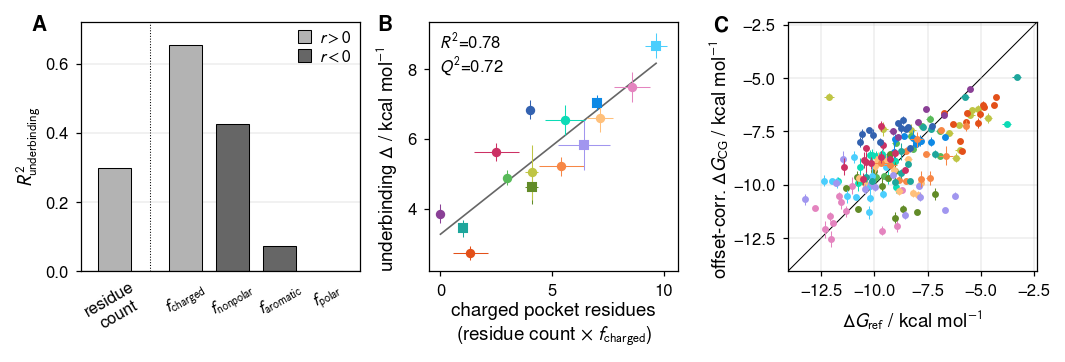

Feature correlation matrix:


,offset,offset_se,n_charged,n_charged_std,f_charged,f_polar,f_aromatic,f_nonpolar,n_res
jnk1,6.837704,0.279389,4.000000,0.000000,0.177207,0.177207,0.000000,0.645586,22.583333
hif2a,5.615615,0.258592,2.500000,1.000000,0.067278,0.464035,0.236509,0.468687,36.666667
mcl1,3.431517,0.233805,1.000000,0.000000,0.053470,0.146720,0.213881,0.799810,19.916667
jak2,5.207828,0.284598,5.416667,0.996205,0.231451,0.196445,0.085776,0.572104,23.250000
cmet,5.814142,0.720244,6.416667,1.164500,0.239390,0.257136,0.144337,0.503474,26.666667
eg5,8.667891,0.355081,9.666667,0.492366,0.348877,0.101363,0.108449,0.549760,27.750000
cdk2,6.600392,0.397197,7.166667,0.577350,0.317525,0.177475,0.133106,0.505000,22.583333
bace,4.615629,0.483465,4.083333,0.288675,0.156135,0.369562,0.197740,0.474303,26.166667
cdk8,7.489534,0.424174,8.583333,0.792961,0.327931,0.191305,0.229567,0.480763,26.166667
mup1,3.855576,0.274972,0.000000,0.000000,0.000000,0.211978,0.324574,0.788022,16.500000


In [ ]:
# Load the data
neutral_only = {t for t in data["target"].unique() if not data[data["target"] == t]["charged"].any()}
offset_corr_data = {}
for i, (name, target_data) in enumerate(iterate_targets(data)):
    d = target_data["dG"] - target_data["fep"]
    offset_corr_data[name] = {
        "offset": d.mean(), "offset_se": d.std() / np.sqrt(len(d)), "color": COLORS[i], "neutral": name in neutral_only,
        "n_charged": target_data["n_charged"].mean(), "n_charged_std": target_data["n_charged"].std(),
        "f_charged": target_data["f_charged"].mean(), "f_polar": target_data["f_polar"].mean(),
        "f_aromatic": target_data["f_aromatic"].mean(), "f_nonpolar": target_data["f_nonpolar"].mean(),
        "n_res": target_data["n_res"].mean(),
    }
offset_corr_data = pd.DataFrame(offset_corr_data).T
num = offset_corr_data.drop(columns=["color", "neutral"]).astype(float)
x, y = num["n_charged"].values, num["offset"].values
b = np.polyfit(x, y, 1)
print('Polynomial fit coefficients:', b)
R2 = pearsonr(x, y).statistic ** 2
loo = np.array([np.polyval(np.polyfit(np.delete(x, i), np.delete(y, i), 1), x[i]) for i in range(len(y))])
Q2 = 1 - ((y - loo) ** 2).sum() / ((y - y.mean()) ** 2).sum()
loo = dict(zip(num.index, loo))
# Setup figure
fig, axs = figure("double", height=2.3, ncols=3)
# Axis 0
bar_order = [("n_res", 0), ("f_charged", 1.5), ("f_nonpolar", 2.5), ("f_aromatic", 3.5), ("f_polar", 4.5)]
x_labels = ["residue\ncount", r"$f_{\mathrm{charged}}$", r"$f_{\mathrm{nonpolar}}$", r"$f_{\mathrm{aromatic}}$", r"$f_{\mathrm{polar}}$"]
xp, vals, dire = [], [], []
for prop, xpos in bar_order:
    r = pearsonr(num[prop], num["offset"]).statistic
    print(f"Pearson r2 for {prop}: {r**2:.3f}")
    xp.append(xpos)
    vals.append(r ** 2)
    dire.append(r > 0)
axs[0].grid(axis="y", alpha=0.2)
axs[0].set_axisbelow(True)
axs[0].bar([k for o, k in zip(dire, xp) if o], [k for o, k in zip(dire, vals) if o], width=0.7, color='0.7', edgecolor="black", lw=0.5)
axs[0].bar([k for o, k in zip(dire, xp) if not o], [k for o, k in zip(dire, vals) if not o], width=0.7, color='0.4', edgecolor="black", lw=0.5)
axs[0].set_ylabel(r"$R^2_{\text{underbinding}}$", labelpad=1)
axs[0].set(ylim=(0, 0.72), xlim=(-0.7, 5.2))
axs[0].axvline(0.75, color="black", lw=0.5, zorder=0, ls=":")
#axs[0].set_yticks([0.0, 0.2, 0.4, 0.6], ["0", ".2", ".4", ".6"])
axs[0].legend(handles=[
    Patch(facecolor='0.7', edgecolor="black", lw=0.5, label=r"$r>0$"),
    Patch(facecolor='0.4', edgecolor="black", lw=0.5, label=r"$r<0$")
], handlelength=0.8, handleheight=0.8, labelspacing=0.15, loc="upper right", frameon=False)
axs[0].set_xticks(xp, x_labels, fontsize=8, rotation=30, ha="center")
axs[0].tick_params(axis="x", labelbottom=True, length=0)
blb = axs[0].annotate("A", xy=(-0.18, 1.03), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
blb.set_in_layout(False)
# Axis 1
for name, row in offset_corr_data.iterrows():
    axs[1].errorbar(row["n_charged"], row["offset"], xerr=row["n_charged_std"], yerr=row["offset_se"],
    fmt="o" if row["neutral"] else "s", markersize=3.5, lw=0.5, mec=row["color"], ecolor=row["color"])
axs[1].plot([x.min(), x.max()], np.polyval(b, [x.min(), x.max()]), color='0.4', lw=0.8, zorder=0)
axs[1].text(0.04, 0.96, f"$R^2$={R2:.2f}\n$Q^2$={Q2:.2f}", transform=axs[1].transAxes, va="top")
axs[1].set_xlabel("charged pocket residues\n(residue count $\\times$ $f_{\\mathrm{charged}}$)", labelpad=1)
axs[1].set_ylabel(r"underbinding $\Delta$ / kcal mol$^{-1}$", y=0.45)
axs[1].set_box_aspect(1)
blb = axs[1].annotate("B", xy=(-0.21, 1.03), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
blb.set_in_layout(False)
# Axis 2
offset_corr_data = []
for i, (name, target_data) in enumerate(iterate_targets(data)):
    axs[2].errorbar(target_data["fep"], target_data["dG"] - loo[name], yerr=target_data["ddG"],
        xerr=target_data["fep-err"], fmt="o", markersize=2.3, lw=0.5, zorder=20 - i)
    offset = (target_data["fep"] - target_data["dG"]).mean()
    offset_corr_data.extend(zip(target_data["fep"], target_data["dG"] - loo[name]))
offset_corr_data = pd.DataFrame(offset_corr_data, columns=["fep", "dG"])
r2_all = r2_score(offset_corr_data["fep"], offset_corr_data["dG"])
mae_all = np.abs(offset_corr_data["fep"] - offset_corr_data["dG"]).mean()
rmsd_all = np.sqrt(np.mean((offset_corr_data["fep"] - offset_corr_data["dG"]) ** 2))
print(f"R2 for all targets: {r2_all:.3f}")
print(f"MAE for all targets: {mae_all:.3f}")
print(f"RMSD for all targets: {rmsd_all:.3f}")
axs[2].set_ylabel(r'offset-corr. $\Delta G_{\mathrm{CG}}$ / kcal mol$^{-1}$', labelpad=1, y=0.45)
axs[2].set_xlabel(r'$\Delta G_{\mathrm{ref}}$ / kcal mol$^{-1}$')
square_with_diagonal(axs[2], pad=0.02, nticks=5)
axs[2].grid(alpha=0.2)
blb = axs[2].annotate("C", xy=(-0.3, 1.03), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
# Export
save_figure(fig, "offset-model")
plt.show()
print("Feature correlation matrix:")
num

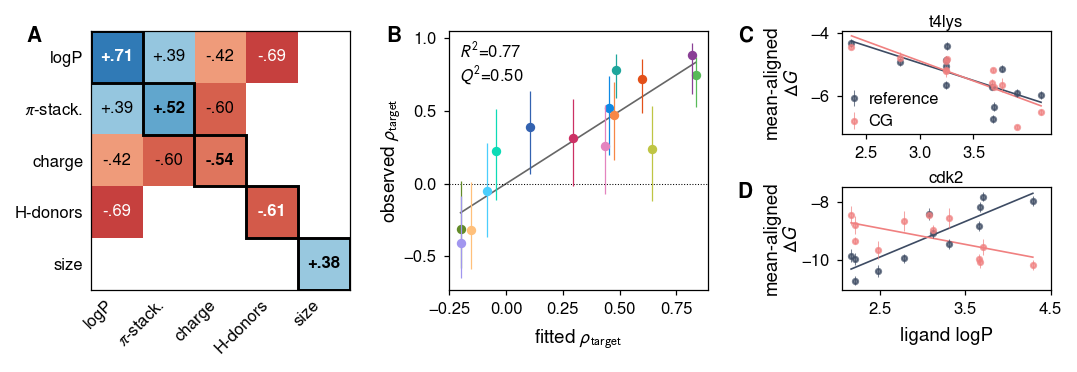

In [ ]:
HEAT = [("sar_logp", "logP"), ("sar_pi_stacking", r"$\pi$-stack."), ("sar_charge", "charge"),
    ("sar_hb_don", "H-donors"), ("sar_size", "size")]
# Setup figure
fig = figure("double", height=2.3, subplots=False)
gs = fig.add_gridspec(nrows=2, ncols=3, height_ratios=[1.0, 1.0], width_ratios=[1.0, 1.0, 0.7])
axs = [fig.add_subplot(g) for g in [gs[:, 0], gs[:, 1], gs[0, 2], gs[1, 2]]]
# Axis 0
keys, labels = zip(*HEAT)
corr = ranking_data[list(keys)].corr().values.copy()
for i, k in enumerate(keys):
    corr[i, i] = pearsonr(ranking_data[k], ranking_data["rho"]).statistic
corr = np.where(abs(corr) > 0.35, corr, np.nan)
im = axs[0].imshow(corr, cmap="RdBu", vmin=-1, vmax=1)
axs[0].set_xticks(range(len(keys)), labels, rotation=45, ha="right")
axs[0].set_yticks(range(len(keys)), labels)
for i in range(len(keys)):
    for j in range(len(keys)):
        if not np.isnan(corr[i, j]):
            color = 'black' if abs(corr[i, j]) < 0.6 else "white"
            text = f"{corr[i, j]:+.2f}".replace("0.", ".")
            axs[0].text(j, i, text, ha="center", va="center", fontsize=8, color=color, fontweight="bold" if i == j else "normal")
    axs[0].add_patch(Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="black", lw=1.4))
axs[0].tick_params(length=0)
axs[0].annotate("A", xy=(-0.25, 0.96), xycoords="axes fraction", fontweight="bold", fontsize=10)
# Axis 1
MODEL_COLS = ["sar_logp", "sar_size", "sar_pi_stacking"]
x, y = ranking_data[MODEL_COLS].values, ranking_data["rho"].values
lin_reg = LinearRegression().fit(x, y)
R2 = lin_reg.score(x, y)
Q2 = r2_score(y, cross_val_predict(lin_reg, x, y, cv=LeaveOneOut()))
y_model = lin_reg.predict(x)
b = np.polyfit(y_model, y, 1)
bounds = np.array([spearman_se(r, n) for r, n in zip(y, ranking_data["n"])])   # (N, 2): rho SE bounds
yerr = np.vstack([y - bounds[:, 0], bounds[:, 1] - y])
for i in range(len(ranking_data)):
    axs[1].errorbar(y_model[i], y[i], yerr=yerr[:, [i]],
        fmt="o", color=COLORS[i], markersize=3.5, elinewidth=0.6, zorder=20 - i)
axs[1].plot([y_model.min(), y_model.max()], np.polyval(b, [y_model.min(), y_model.max()]), color="0.4", lw=0.8, zorder=0)
axs[1].text(0.04, 0.96, f"$R^2$={R2:.2f}\n$Q^2$={Q2:.2f}", transform=axs[1].transAxes, va="top")
axs[1].set_xlabel(r"fitted $\rho_{\mathrm{target}}$")
axs[1].set_ylabel(r"observed $\rho_{\mathrm{target}}$", labelpad=0)
axs[1].axhline(0, color="black", ls=":", lw=0.5, zorder=0)
axs[1].set_box_aspect(1)
axs[1].annotate("B", xy=(-0.24, 0.96), xycoords="axes fraction", fontweight="bold", fontsize=10)
# Axis 2 and 3
best = ranking_data.loc[ranking_data["sar_logp"].idxmax(), "target"]  # closest logP-following series
for ax, target, letter, xticks in [(axs[2], "t4lys", "C", [2.5, 3.0, 3.5]), (axs[3], "cdk2", "D", [2.5, 3.5, 4.5])]:
    g = lig[lig["target"] == target]
    for col, color, label in [("fep", C_POS, "reference"), ("dG", "lightcoral", "CG")]:
        offset = 0 if col == "fep" else (g['dG'] - g['fep']).mean()
        ax.errorbar(g["logp"], g[col] - offset, yerr=g['fep-err' if col == "fep" else "ddG"], color=color, label=label, fmt="o", markersize=2.5, lw=0.5, alpha=0.7)
        xs = np.array([g["logp"].min(), g["logp"].max()])
        ax.plot(xs, np.polyval(np.polyfit(g["logp"], g[col] - offset, 1), xs), color=color, lw=0.8, zorder=1)
    ax.set_title(target, fontsize=8, pad=2)
    ax.set_ylabel("mean-aligned\n" + r"$\Delta G$", labelpad=4.3 if target == "t4lys" else 0)
    ax.set_xticks(xticks)
    ax.annotate(letter, xy=(-0.5, 0.90), xycoords="axes fraction", fontweight="bold", fontsize=10)
axs[2].legend(handlelength=1, handletextpad=0.4, borderpad=0.2, fontsize=8, loc="best")
axs[3].set_xlabel("ligand logP")
fig.get_layout_engine().set(wspace=0.03, hspace=0, w_pad=0.01, h_pad=0.01)
# Export
save_figure(fig, "ranking-model")
plt.show()

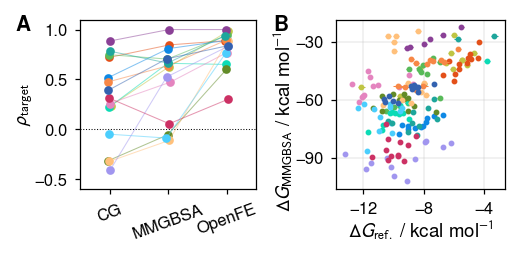

In [6]:
spearman_rhos = []
for i, (name, target_data) in enumerate(iterate_targets(data)):
    spearman_rhos.append((
        spearmanr(target_data["fep"], target_data["dG"]).statistic,
        spearmanr(target_data["fep"], target_data["MMGBSA"]).statistic,
        spearmanr(target_data["fep"], target_data["openfe-dg"]).statistic,
    ))
# Create figure
fig, axs = figure("single", height=1.6, ncols=2, gridspec_kw={"width_ratios": [5, 5]})
# Setup axis 0
for i, row in enumerate(spearman_rhos):
    xoff = np.random.normal(0, 0.02, size=len(row))
    axs[0].plot(np.array([0, 1, 2]) + xoff, row, color=COLORS[i], lw=0.5, zorder=20 - i, alpha=0.5)
    axs[0].scatter(np.array([0, 1, 2]) + xoff, row, color=COLORS[i], s=10, zorder=20 - i)
axs[0].set(xticks=[0, 1, 2], ylim=(-0.6, 1.1), xlim=(-0.5, 2.5))
axs[0].set_xticklabels(["CG", "MMGBSA", "OpenFE"], rotation=20, ha="center")
axs[0].set_ylabel(r"$\rho_{\mathrm{target}}$", labelpad=0)
axs[0].axhline(0, color="black", lw=0.5, zorder=0, ls=":")
axs[0].annotate("A", xy=(-0.37, 1.03), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
# Setup axis 1
for i, (name, target_data) in enumerate(iterate_targets(data)):
    axs[1].errorbar(target_data["fep"], target_data["MMGBSA"],
        xerr=target_data["fep-err"], fmt="o", markersize=1.8, lw=0.5, zorder=20 - i)
#axs[1].set_aspect("equal", adjustable="datalim")
#axs[1].margins(y=0.1)
axs[1].set_box_aspect(1)
axs[1].set_xlabel(r"$\Delta G_{\mathrm{ref.}}$ / kcal mol$^{-1}$", labelpad=0)
axs[1].set_ylabel(r"$\Delta G_{\mathrm{MMGBSA}}$ / kcal mol$^{-1}$", labelpad=0, y=0.4)
axs[1].xaxis.set_major_locator(MaxNLocator(nbins=3))
axs[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axs[1].annotate("B", xy=(-0.37, 1.03), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
axs[1].grid(alpha=0.2)
# Export
save_figure(fig, "spearman-rhos-mmgbsa")
plt.show()

CG MAE: 5.034494360382178
MMGBSA MAE: 34.8881818337874
OpenFE MAE: 1.1512978929030722


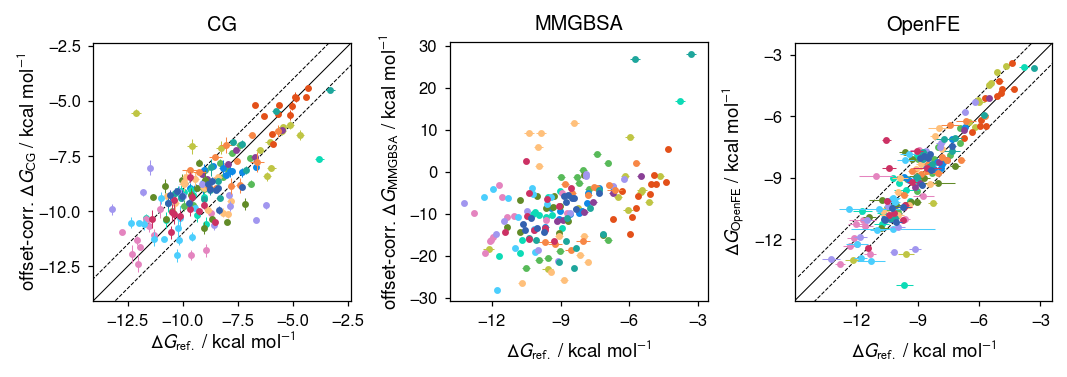

In [9]:
fig, axs = figure('double', height=2.4, ncols=3)
for i, (name, target_data) in enumerate(iterate_targets(data)):
    offset = (target_data["fep"] - target_data["dG"]).mean()
    offsets_MMGBSA = (target_data["fep"] - target_data["MMGBSA"]).mean()
    axs[0].errorbar(target_data["fep"], target_data["dG"] + offset, yerr=target_data["ddG"],
        xerr=target_data["fep-err"], fmt="o", markersize=2.3, lw=0.5, zorder=20 - i)
    axs[1].errorbar(target_data["fep"], target_data["MMGBSA"] + offsets_MMGBSA,
        xerr=target_data["fep-err"], fmt="o", markersize=2.3, lw=0.5, zorder=20 - i)
    axs[2].errorbar(target_data["fep"], target_data["openfe-dg"],
        xerr=target_data["openfe-err"], fmt="o", markersize=2.3, lw=0.5, zorder=20 - i)
print('CG MAE:', np.mean(np.abs(target_data["fep"] - target_data["dG"])))
print('MMGBSA MAE:', np.mean(np.abs(target_data["fep"] - target_data["MMGBSA"])))
print('OpenFE MAE:', np.mean(np.abs(target_data["fep"] - target_data["openfe-dg"])))
# Setup axis 0
lim = np.array((axs[0].get_xlim()[0] - 1, axs[0].get_xlim()[1] + 1))
axs[0].set_xlabel(r"$\Delta G_{\mathrm{ref.}}$ / kcal mol$^{-1}$", labelpad=0)
axs[0].set_ylabel(r"offset-corr. $\Delta G_{\mathrm{CG}}$ / kcal mol$^{-1}$", labelpad=0)
square_with_diagonal(axs[0], pad=0.02, nticks=5)
axs[0].plot(lim, lim + 1, color="black", lw=0.5, zorder=0, ls="--")
axs[0].plot(lim, lim - 1, color="black", lw=0.5, zorder=0, ls="--")
axs[0].set(title='CG')
# Setup axis 1
axs[1].xaxis.set_major_locator(MaxNLocator(nbins=4))
#axs[1].set_box_aspect(1)
#square_with_diagonal(axs[1], pad=0.02, nticks=5)
axs[1].set(title='MMGBSA', xlabel=r"$\Delta G_{\mathrm{ref.}}$ / kcal mol$^{-1}$", ylabel=r"offset-corr. $\Delta G_{\mathrm{MMGBSA}}$ / kcal mol$^{-1}$")
# Setup axis 2
square_with_diagonal(axs[2], pad=0.02, nticks=5)
axs[2].plot(lim, lim + 1, color="black", lw=0.5, zorder=0, ls="--")
axs[2].plot(lim, lim - 1, color="black", lw=0.5, zorder=0, ls="--")
axs[2].set(title="OpenFE", xlabel=r"$\Delta G_{\mathrm{ref.}}$ / kcal mol$^{-1}$", ylabel=r"$\Delta G_{\mathrm{OpenFE}}$ / kcal mol$^{-1}$")
plt.show()

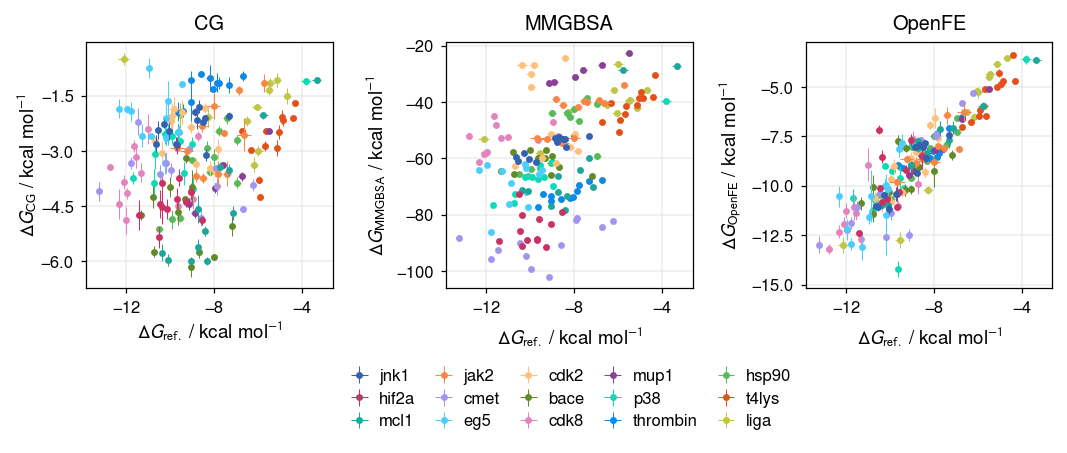

In [4]:
fig = figure('double', height=2.9, subplots=False)
gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.15])
axs = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_leg = fig.add_subplot(gs[1, :])
for i, (name, target_data) in enumerate(iterate_targets(data)):
    axs[0].errorbar(target_data["fep"], target_data["dG"], yerr=target_data["ddG"],
        xerr=target_data["fep-err"], fmt="o", markersize=2.3, lw=0.5, zorder=20 - i, label=name)
    axs[1].errorbar(target_data["fep"], target_data["MMGBSA"],
        xerr=target_data["fep-err"], fmt="o", markersize=2.3, lw=0.5, zorder=20 - i)
    axs[2].errorbar(target_data["fep"], target_data["openfe-dg"], yerr=target_data["openfe-err"],
        xerr=target_data["fep-err"], fmt="o", markersize=2.3, lw=0.5, zorder=20 - i)
# Setup axis 0
axs[0].set_xlabel(r"$\Delta G_{\mathrm{ref.}}$ / kcal mol$^{-1}$", labelpad=1)
axs[0].set_ylabel(r"$\Delta G_{\mathrm{CG}}$ / kcal mol$^{-1}$", labelpad=1)
axs[0].set(title='CG')
axs[0].set_box_aspect(1)
axs[0].grid(alpha=0.2)
axs[0].yaxis.set_major_locator(MaxNLocator(nbins=5))
axs[0].xaxis.set_major_locator(MaxNLocator(nbins=3))
# Setup axis 1
axs[1].set_box_aspect(1)
axs[1].set(title='MMGBSA', xlabel=r"$\Delta G_{\mathrm{ref.}}$ / kcal mol$^{-1}$", ylabel=r"$\Delta G_{\mathrm{MMGBSA}}$ / kcal mol$^{-1}$")
axs[1].grid(alpha=0.2)
axs[1].yaxis.set_major_locator(MaxNLocator(nbins=5))
axs[1].xaxis.set_major_locator(MaxNLocator(nbins=3))
# Setup axis 2
axs[2].set_box_aspect(1)
axs[2].set(title="OpenFE", xlabel=r"$\Delta G_{\mathrm{ref.}}$ / kcal mol$^{-1}$", ylabel=r"$\Delta G_{\mathrm{OpenFE}}$ / kcal mol$^{-1}$")
axs[2].grid(alpha=0.2)
axs[2].yaxis.set_major_locator(MaxNLocator(nbins=5))
axs[2].xaxis.set_major_locator(MaxNLocator(nbins=3))
# Add legend
ax_leg.axis("off")
handles, labels = axs[0].get_legend_handles_labels()
ax_leg.legend(handles, labels, ncol=5, loc='center', frameon=False)
# Export
save_figure(fig, "si-full-scatter-comparison")
plt.show()

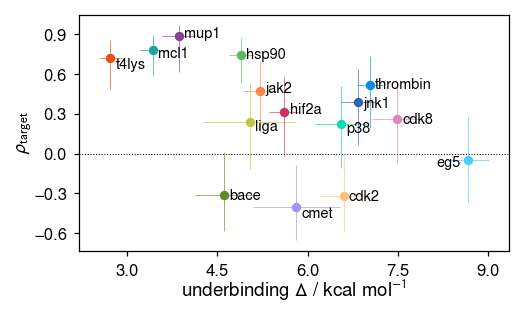

In [11]:
fig, axs = figure('single', height=2.0, ncols=1, nrows=1)
for i, (name, target_data) in enumerate(iterate_targets(data)):
    offset = (target_data["fep"] - target_data["dG"]).mean()
    offset_se = (target_data["fep"] - target_data["dG"]).std() / np.sqrt(len(target_data))
    rho = spearmanr(target_data["fep"], target_data["dG"]).statistic
    rho_le, rho_he = spearman_se(rho, len(target_data))
    axs.errorbar(-offset, rho, yerr=[[rho - rho_le], [rho_he - rho]], xerr=offset_se, fmt="o", label=name, zorder=20 - i, lw=0.3)
    xydict = defaultdict(lambda: (2.5, 0), {'mcl1': (2.5, -1.5), 'mup1': (2.5, 1.5), 'cmet': (2.3, -3), 'eg5': (-15, -1),
        'jak2': (2.5, 1), 'p38': (2.5, -2.3), 'liga': (2.5, -2), 'jnk1': (2.5, -1.0), 't4lys': (2.5, -3), 'hif2a': (2.5, 1.0)})
    axs.annotate(name, xy=(-offset, rho), xytext=xydict[name], textcoords="offset points", ha="left", va="center", fontsize=7, zorder=30)
axs.set_xlabel(r"underbinding $\Delta$ / kcal mol$^{-1}$", labelpad=-1)
axs.set_ylabel(r"$\rho_{\mathrm{target}}$", labelpad=0)
axs.axhline(0, color="black", ls=":", lw=0.5, zorder=0)
axs.xaxis.set_major_locator(MaxNLocator(nbins=5))
axs.yaxis.set_major_locator(MaxNLocator(nbins=7))
save_figure(fig, "offset-corr-rho")
plt.show()

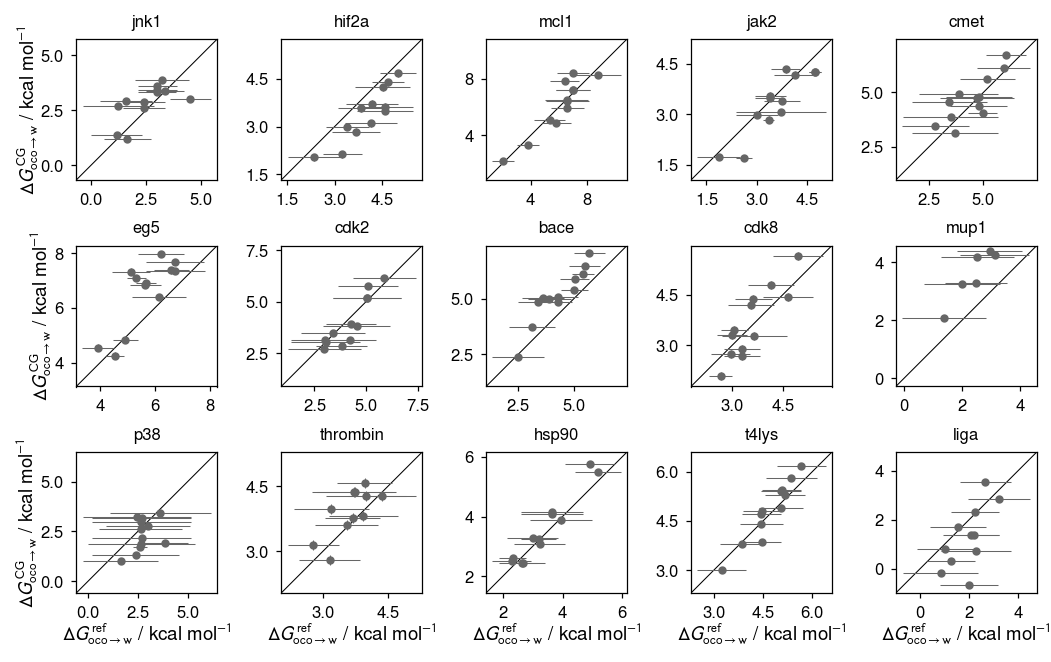

In [101]:
fig, axs = figure("double", height=4.3, ncols=5, nrows=3)
for i, (name, target_data) in enumerate(iterate_targets(data)):
    mean_ocow = target_data[LOGP_REF_KEYS].mean(axis=1)
    std = (target_data[LOGP_REF_KEYS]).std(axis=1)
    ax = axs[i // 5, i % 5]
    ax.errorbar(mean_ocow, target_data["oco-w-dG"], xerr=std, yerr=target_data["oco-w-ddG"], fmt='o', markersize=3, lw=0.5, color='0.4')
    ax.set_title(name, fontsize=8)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    square_with_diagonal(ax, nticks=3)
    if i % 5 == 0:
        ax.set_ylabel(r"$\Delta G^{\mathrm{CG}}_{\mathrm{oco}\rightarrow\mathrm{w}}$ / kcal mol$^{-1}$", labelpad=0)
    if i // 5 == 2:
        ax.set_xlabel(r"$\Delta G^{\mathrm{ref}}_{\mathrm{oco}\rightarrow\mathrm{w}}$ / kcal mol$^{-1}$", labelpad=0)
save_figure(fig, "si-oco-w-dg")
plt.show()

0.8126107032724816
jak2_6: 0.617 (7 scores)
liga_10: 0.635 (4 scores)
Bonded score counts: <0.3: 15, 0.3-0.5: 141, >0.5: 2


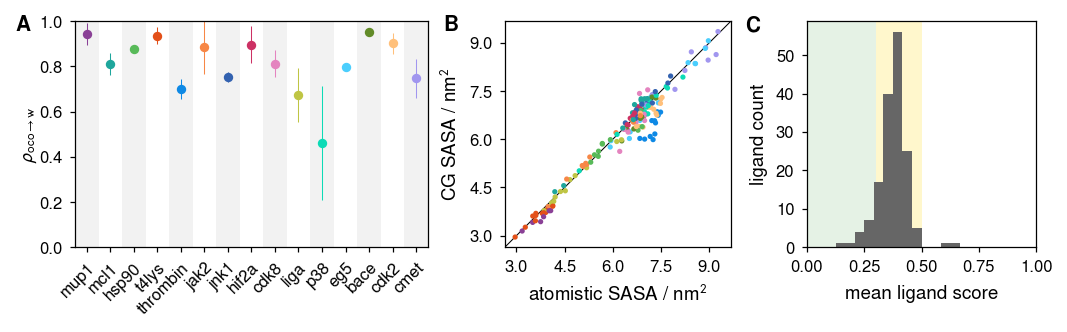

In [ ]:
def logp_ocow_rho(target_data):
    """Spearman(mean predicted logP, CG octanol->water dG) with a jackknife SE over the
    logP reference methods (leave one LOGP_REF_KEYS out at a time)."""
    rho = lambda keys: spearmanr(target_data[keys].mean(axis=1), target_data["oco-w-dG"]).statistic
    loo = np.array([rho([k for k in LOGP_REF_KEYS if k != drop]) for drop in LOGP_REF_KEYS])
    k = len(LOGP_REF_KEYS)
    return rho(LOGP_REF_KEYS), np.sqrt((k - 1) / k * ((loo - loo.mean()) ** 2).sum())
fig, axs = figure("double", height=2.1, ncols=3, gridspec_kw={'width_ratios':[2,1.3,1.3]})
# Axis 0
correlation_data = {}
for name, target_data in iterate_targets(data):
    rho_oco_w, err_oco_w = logp_ocow_rho(target_data)
    rho_dG = spearmanr(target_data["fep"], target_data["dG"]).statistic
    correlation_data[name] = (rho_oco_w, err_oco_w, rho_dG)
print('Median correlation: ', np.median([v[0] for v in correlation_data.values()]))
correlation_data = dict(sorted(correlation_data.items(), key=lambda x: x[1][2], reverse=True))
for i, (name, (rho_oco_w, err_oco_w, rho_dG)) in enumerate(correlation_data.items()):
    axs[0].errorbar(i, rho_oco_w, yerr=err_oco_w, color=COLORS[data["target"].unique().tolist().index(name)], fmt="o", markersize=3.5, lw=0.5)
axs[0].set_xticks(range(len(correlation_data)), correlation_data.keys(), rotation=45, ha="right", fontsize=8, rotation_mode="anchor")
axs[0].set_ylabel(r"$\rho_{\mathrm{oco}\rightarrow\mathrm{w}}$", labelpad=0)
axs[0].set_ylim(0.0, 1.0)
axs[0].annotate("A", xy=(-0.17, 1.03), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
axs[0].set_xlim(-0.5, len(correlation_data) - 0.5)
for i in range(0, len(correlation_data), 2):
    axs[0].axvspan(i - 0.5, i + 0.5, color="0.95", lw=0, zorder=-1)
# Axis 1
axs[1].scatter(data["atom-sasa"], data["cg-sasa"], s=2.3, c=[COLORS[data["target"].unique().tolist().index(t)] for t in data["target"]])
axs[1].set_xlabel("atomistic SASA / nm$^2$")
axs[1].set_ylabel("CG SASA / nm$^2$")
square_with_diagonal(axs[1], nticks=5)
axs[1].annotate("B", xy=(-0.27, 1.03), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
# Axis 2
score_counts = [0, 0, 0]
mean_bond_scores = {}
for system, bs in bonded_scores.items():
    combined_scores = bs["bonds"] + bs["angles"] + bs["dihedrals"]
    if len(combined_scores) > 0:
        mean_bond_scores[system] = np.mean(combined_scores)
        if mean_bond_scores[system] < 0.3:
            score_counts[0] += 1
        elif mean_bond_scores[system] < 0.5:
            score_counts[1] += 1
        else:
            score_counts[2] += 1
            print(f"{system}: {mean_bond_scores[system]:.3f} ({len(combined_scores)} scores)")
print(f"Bonded score counts: <0.3: {score_counts[0]}, 0.3-0.5: {score_counts[1]}, >0.5: {score_counts[2]}")
axs[2].hist(mean_bond_scores.values(), bins=np.linspace(0, 1, 25), color="0.4")
axs[2].set(xlim=(0, 1), xlabel="mean ligand score", ylabel="ligand count")
axs[2].axvspan(0, 0.3, color="green", alpha=0.1, zorder=-1, lw=0)
axs[2].axvspan(0.3, 0.5, color="gold", alpha=0.2, zorder=-1, lw=0)
axs[2].annotate("C", xy=(-0.27, 1.03), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
# Export
save_figure(fig, "si-ligand-validation")
plt.show()

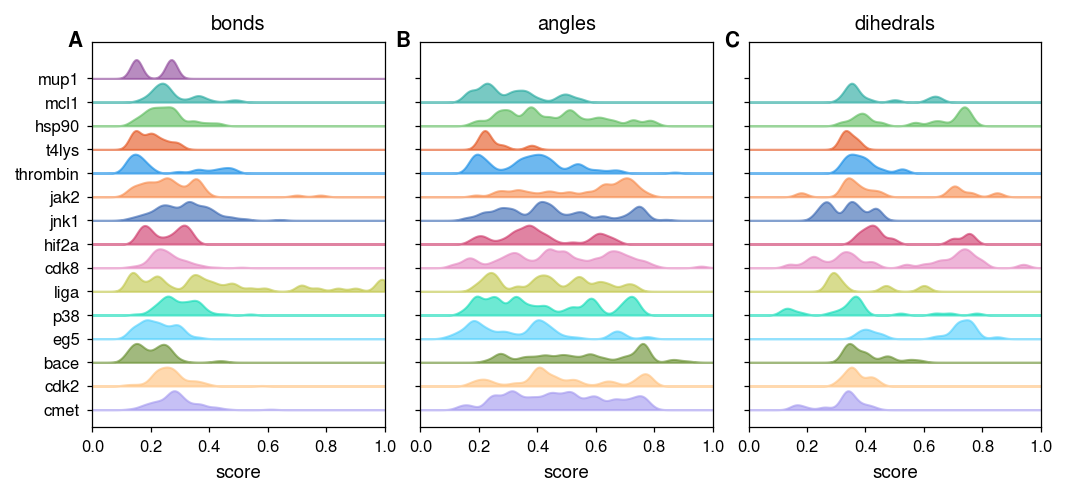

In [7]:
# Prepare data
bond_score_acc = {}
for target in list(correlation_data.keys())[::-1]:
    bond_score_acc[target] = {'bonds': [], 'angles': [], 'dihedrals': []}
    for name, score_data in bonded_scores.items():
        if name.startswith(target):
            for key in ['bonds', 'angles', 'dihedrals']:
                bond_score_acc[target][key].extend(score_data[key])
# Setup figure
fig, axs = figure("double", height=3.2, ncols=3, sharey=True)
for k, (ax, col) in enumerate(zip(axs, ['bonds', 'angles', 'dihedrals'])):
    for i, (target, scores) in enumerate(bond_score_acc.items()):
        if len(scores[col]) > 0:
            v = np.asarray(scores[col], float)
            x = np.linspace(0, 1, 200)
            y = gaussian_kde(v, bw_method=0.02 / v.std(ddof=1))(x)
            ax.fill_between(x, i, i + 0.8 * y / y.max(), alpha=0.6, lw=1, color=COLORS[data["target"].unique().tolist().index(target)])
    ax.set(title=col, xlim=(0, 1), xlabel="score")
    lbl = ax.annotate(chr(65 + k), xy=(-0.085, 1.03), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
    lbl.set_in_layout(False)
axs[0].set_yticks(range(len(bond_score_acc)), list(bond_score_acc.keys()))
# Export
save_figure(fig, "si-bonded-score-distribution")
plt.show()

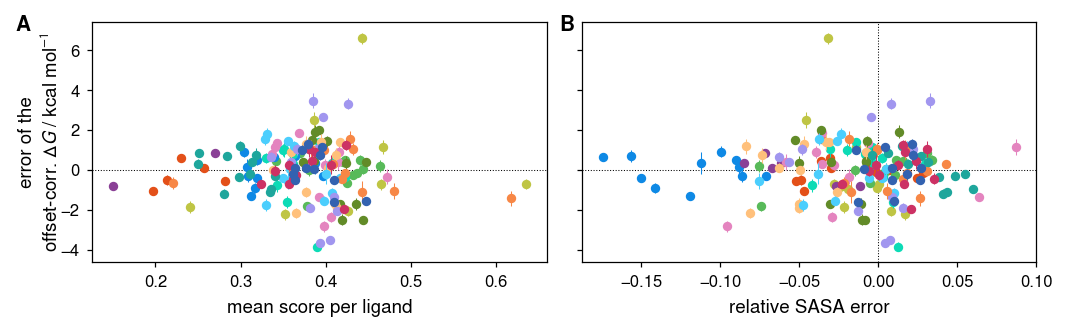

In [11]:
fig, axs = figure("double", height=2.1, ncols=2, sharey=True)
# Axis 0 and 1
for i, (target, target_data) in enumerate(iterate_targets(data)):
    offset = (target_data["fep"] - target_data["dG"]).mean()
    resid = target_data["dG"] + offset - target_data["fep"]
    bsc = [mean_bond_scores.get(t, np.nan) for t in target_data["system"]]
    sasa_re = target_data["cg-sasa"] / target_data["atom-sasa"] - 1
    #sasa_re_err = np.sqrt((target_data["cg-sasa-std"] / target_data["cg-sasa"])**2 + (target_data["atom-sasa-std"] / target_data["atom-sasa"])**2) * sasa_re
    yerr = np.hypot(target_data["ddG"], target_data["fep-err"])
    axs[0].errorbar(bsc, resid, yerr=yerr, fmt="o", zorder=20 - i, lw=0.5)
    axs[1].errorbar(sasa_re, resid, yerr=yerr, fmt="o", zorder=20 - i, lw=0.5)
# Setup axis 0
axs[0].set_xlabel("mean score per ligand")
axs[0].axhline(0.0, color="black", ls=":", lw=0.5, zorder=0)
axs[0].set_ylabel("error of the\noffset-corr. " + r"$\Delta G$ / kcal mol$^{-1}$", labelpad=0)
axs[0].annotate("A", xy=(-0.17, 1.03), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
# Setup axis 1
axs[1].set_xlabel("relative SASA error")
axs[1].axhline(0.0, color="black", ls=":", lw=0.5, zorder=0)
axs[1].axvline(0.0, color="black", ls=":", lw=0.5, zorder=0)
lbl = axs[1].annotate("B", xy=(-0.05, 1.03), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
#lbl.set_in_layout(False)
# Export
save_figure(fig, "si-residual-vs-ligand-metrics")
plt.show()

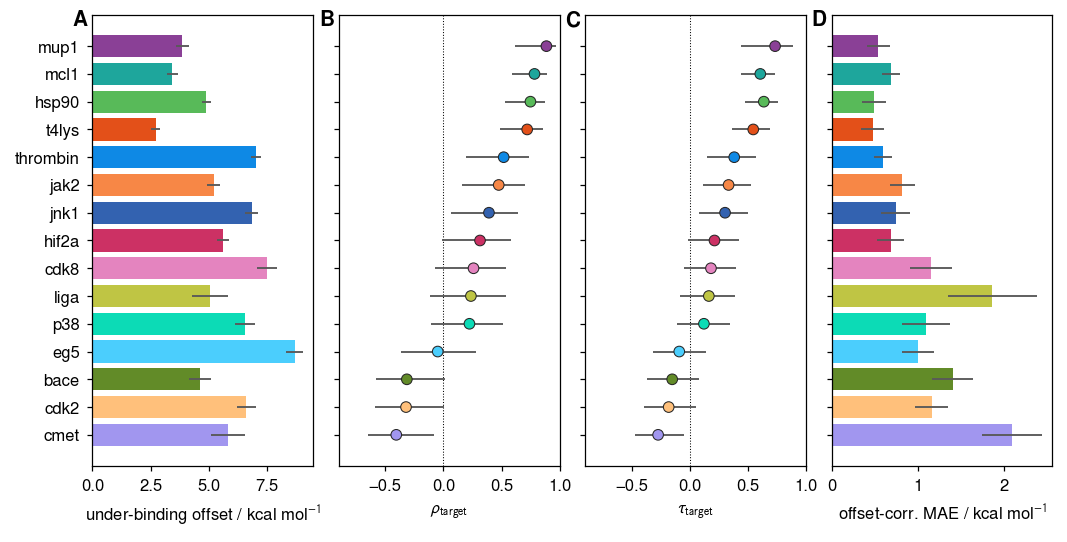

In [ ]:
def offset_stat(x, y):
    d = np.asarray(x, float) - np.asarray(y, float)
    m, se = d.mean(), d.std(ddof=1) / np.sqrt(len(d))
    return m, m - se, m + se

def mae_stat(x, y):
    d = np.asarray(x, float) - np.asarray(y, float)
    a = np.abs(d - d.mean())
    m, se = a.mean(), a.std(ddof=1) / np.sqrt(len(a))
    return m, m - se, m + se

def rho_stat(x, y):
    r = spearmanr(x, y).statistic
    return (r, *spearman_se(r, len(x)))

def tau_stat(x, y):
    t = kendalltau(x, y).statistic
    return (t, *kendall_se(t, len(x)))

METRICS = {"offset": offset_stat, "rho": rho_stat, "tau": tau_stat, "mae": mae_stat}
rows = {}
for i, (name, td) in enumerate(iterate_targets(data)):
    r = {"color": COLORS[i]}
    for k, fn in METRICS.items():
        r[k], r[k + "_lo"], r[k + "_hi"] = fn(td["fep"], td["dG"])
    rows[name] = r
props = pd.DataFrame(rows).T.sort_values("rho", ascending=False)
# Setup figure
colors = list(props.pop("color")); props = props.astype(float)
fig, axs = figure("double", height=3.5, ncols=4, nrows=1, sharey=True)
y = np.arange(len(props))
# Draw panels
PANELS = [ # (col, x-label, sign, zero-line, kind)
    ("offset", r"under-binding offset / kcal mol$^{-1}$",  -1, False, "bar"),
    ("rho",    r"$\rho_{\mathrm{target}}$",           1, True,  "dot"),
    ("tau",    r"$\tau_{\mathrm{target}}$",           1, True,  "dot"),
    ("mae",    r"offset-corr. MAE / kcal mol$^{-1}$", 1, False, "bar"),
]
for i, (ax, (key, xlabel, s, zero, kind)) in enumerate(zip(axs, PANELS)):
    v  = s * props[key].values
    lo = s * props[key + "_lo"].values
    hi = s * props[key + "_hi"].values
    lower, upper = np.minimum(lo, hi), np.maximum(lo, hi) # s=-1 swaps the bounds
    if zero:
        ax.axvline(0, color="black", ls=":", lw=0.5, zorder=0)
    if kind == "bar":
        ax.barh(y, v, color=colors, zorder=2)
    ax.hlines(y, lower, upper, color="0.35", lw=0.9, zorder=4) # CI whisker
    if kind == "dot":
        ax.scatter(v, y, c=colors, s=26, edgecolor="0.15", lw=0.5, zorder=6)
        ax.set_xlim(-0.9, 1.0)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=8)
    l = ax.annotate(chr(65 + i), xy=(-0.09, 1.01), xycoords="axes fraction", ha="left", va="top", fontweight="bold", fontsize=10)
    l.set_in_layout(False)
axs[0].set_yticks(y); axs[0].set_yticklabels(props.index, fontsize=8); axs[0].invert_yaxis()
# Fix layout
fig.canvas.draw()
p = [a.get_position() for a in axs]
w, h, x0, y0 = p[0].width, p[0].height, p[0].x0, p[0].y0
gap = np.mean([p[i + 1].x0 - p[i].x1 for i in range(len(axs) - 1)])
fig.set_layout_engine("none")
for i, a in enumerate(axs):
    a.set_position([x0 + i * (w + gap), y0, w, h])
# Export
save_figure(fig, "si-free-energy-stats")
plt.show()

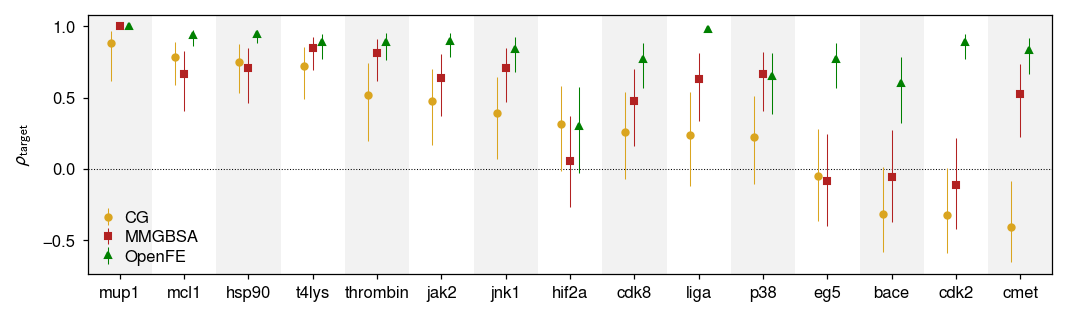

In [100]:
corr_comp_data = {}
for name, target_data in iterate_targets(data):
    corr_comp_data[name] = {}
    for method, key in [("CG", "dG"), ("MMGBSA", "MMGBSA"), ("OpenFE", "openfe-dg")]:
        rho = spearmanr(target_data["fep"], target_data[key]).statistic
        lo, hi = spearman_se(rho, len(target_data))
        corr_comp_data[name][method] = (rho, lo, hi)
corr_comp_data = dict(sorted(corr_comp_data.items(), key=lambda x: x[1]["CG"][0], reverse=True))
fig, axs = figure("double", height=2.0, ncols=1, nrows=1)
handles = [None] * 3
# Plot dots with error bars
for i, (target, target_data) in enumerate(corr_comp_data.items()):
    for j, (method, (rho, lo, hi)) in enumerate(target_data.items()):
        handles[j] = axs.errorbar(i + 0.14 * (j - 1), rho, yerr=[[rho - lo], [hi - rho]],
            fmt=["o", "s", "^"][j], markersize=3, lw=0.5, color=["goldenrod", "firebrick", "green"][j])
# Setup axis
axs.axhline(0, color="black", ls=":", lw=0.5, zorder=0)
axs.set(xticks=np.arange(len(corr_comp_data)), ylabel=r"$\rho_{\mathrm{target}}$")
axs.set_xticklabels(corr_comp_data.keys(), fontsize=8)
axs.legend(handles, ["CG", "MMGBSA", "OpenFE"], fontsize=8, frameon=False, handletextpad=0.3, labelspacing=0.2)
# Add alternating background shading to improve readability
axs.set_xlim(-0.5, len(corr_comp_data) - 0.5)
for i in range(0, len(corr_comp_data), 2):
    axs.axvspan(i - 0.5, i + 0.5, color="0.95", lw=0, zorder=-1)
# Export
save_figure(fig, "si-correlation-comparison")
plt.show()

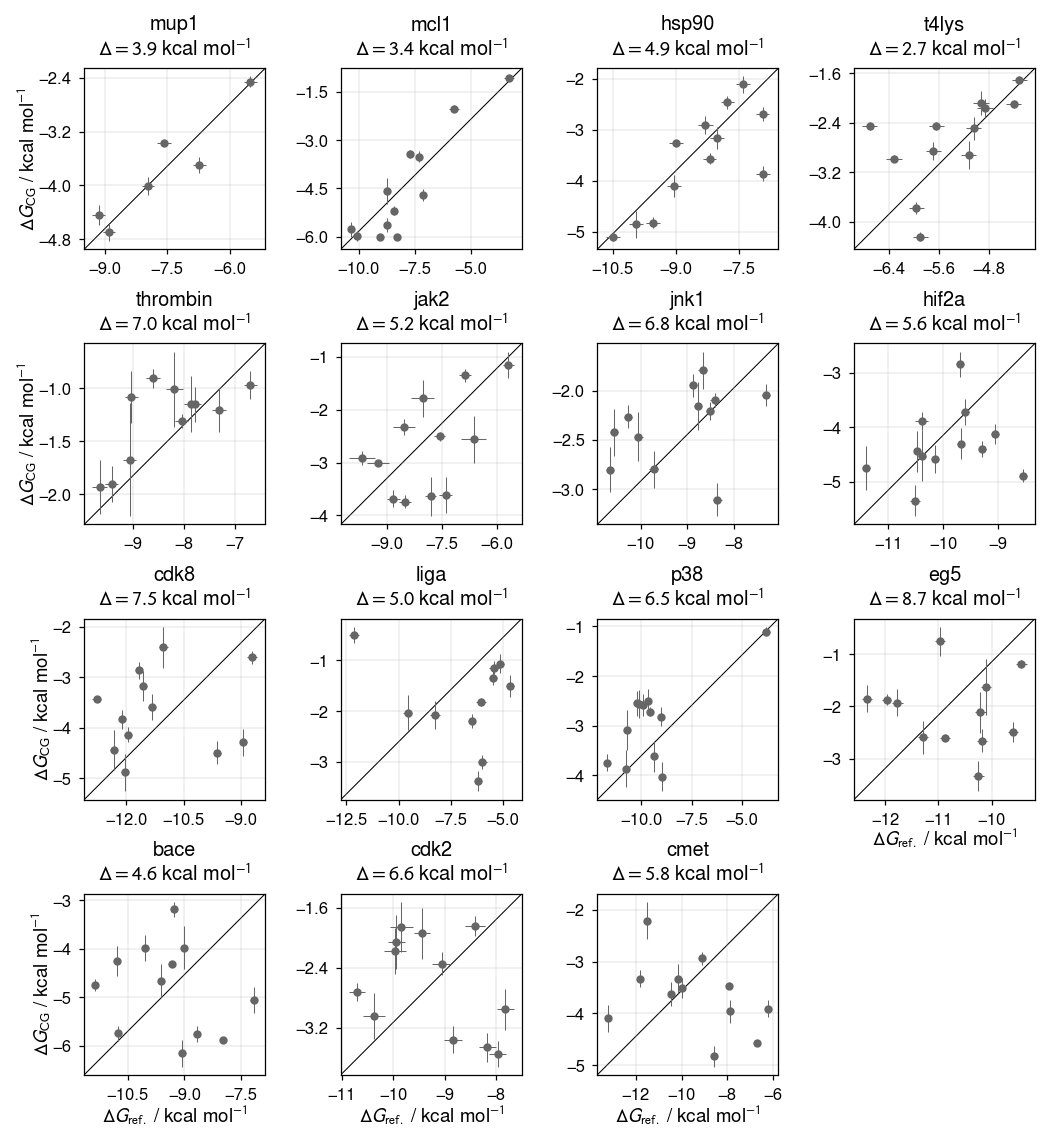

In [8]:
fig, axs = figure("double", height=7.5, ncols=4, nrows=4)
for i, (name, target_data) in enumerate(sorted(iterate_targets(data), key=lambda x: spearmanr(x[1]["fep"], x[1]["dG"]).statistic, reverse=True)):
    ax = axs[i // 4, i % 4]
    ax.errorbar(target_data["fep"], target_data["dG"], yerr=target_data["ddG"],
        xerr=target_data["fep-err"], fmt="o", markersize=3, lw=0.5, color='0.4')
    offset = (target_data["dG"] - target_data["fep"]).mean()
    offset_text = f"$\\Delta={offset:.1f}$ kcal mol$^{{-1}}$"
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.set(title=f'{name}\n{offset_text}', xlim=xlim, ylim=ylim)
    ax.set_box_aspect(1)
    ax.plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="black", lw=0.5, zorder=0)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.grid(alpha=0.2)
    if i % 4 == 0:
        ax.set_ylabel(r"$\Delta G_{\mathrm{CG}}$ / kcal mol$^{-1}$", labelpad=0)
    if i >= 12:
        ax.set_xlabel(r"$\Delta G_{\mathrm{ref.}}$ / kcal mol$^{-1}$", labelpad=0)
# Handle empty subplot
lbl = axs[2,3].annotate(r"$\Delta G_{\mathrm{ref.}}$ / kcal mol$^{-1}$", xy=(0.5, -0.25), xycoords="axes fraction", ha="center", fontsize=9)
lbl.set_in_layout(False)
fig.delaxes(axs[3, 3])
# Export
save_figure(fig, "si-all-target-scatterplots")
plt.show()

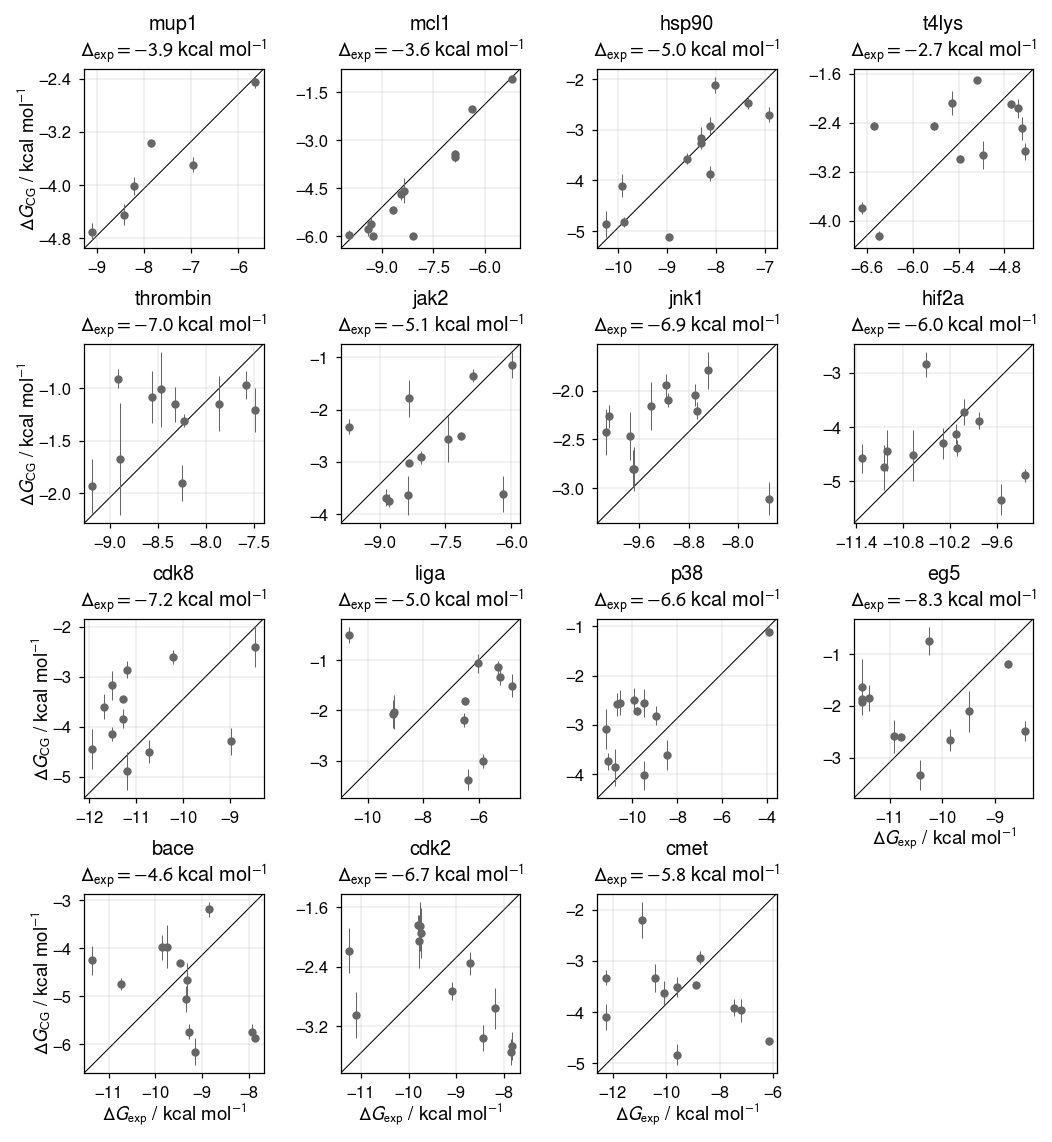

In [7]:
fig, axs = figure("double", height=7.5, ncols=4, nrows=4)
for i, (name, target_data) in enumerate(sorted(iterate_targets(data), key=lambda x: spearmanr(x[1]["fep"], x[1]["dG"]).statistic, reverse=True)):
    ax = axs[i // 4, i % 4]
    ax.errorbar(target_data["exp"], target_data["dG"], yerr=target_data["ddG"],
        fmt="o", markersize=3, lw=0.5, color='0.4')
    offset = (target_data["exp"] - target_data["dG"]).mean()
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    offset_text = f"$\\Delta_{{\\mathrm{{exp}}}}={offset:.1f}$ kcal mol$^{{-1}}$"
    ax.set(title=f'{name}\n{offset_text}', xlim=xlim, ylim=ylim)
    ax.set_box_aspect(1)
    ax.plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="black", lw=0.5, zorder=0)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.grid(alpha=0.2)
    if i % 4 == 0:
        ax.set_ylabel(r"$\Delta G_{\mathrm{CG}}$ / kcal mol$^{-1}$", labelpad=0)
    if i >= 12:
        ax.set_xlabel(r"$\Delta G_{\mathrm{exp}}$ / kcal mol$^{-1}$", labelpad=0)
# Handle empty subplot
lbl = axs[2,3].annotate(r"$\Delta G_{\mathrm{exp}}$ / kcal mol$^{-1}$", xy=(0.5, -0.25), xycoords="axes fraction", ha="center", fontsize=9)
lbl.set_in_layout(False)
fig.delaxes(axs[3, 3])
# Export
save_figure(fig, "si-all-target-scatterplots-exp")
plt.show()

In [ ]:
ranking_data_p = ranking_data.sort_values("rho", ascending=False).set_index("target")
ranking_data_p.columns = [c.replace("sar_", "") for c in ranking_data_p.columns]
column_map = {
    "logp": "logP", "pi_stacking": r"$\pi$\\stacking", "hb_don": r"H\\donors",
    'rho': r'$\rho_{\mathrm{target}}$', 'hb_acc': r"H\\acceptors", 'water': r'pocket\\water',
    'hb': r"total H\\bonds", 'salt': r"salt-\\bridges", 'pi_cation': r"$\pi$-cation", 'hydrophobic': r"hydrophobic\\contacts"
}
ranking_data_p = ranking_data_p.rename(columns=column_map)
ranking_data_p.columns = [rf'\thead{{{v}}}' for v in ranking_data_p.columns]
with open(FIGURE_DIR / "si-ranking-data.tex", "w") as f:
    ranking_data_p.to_latex(f, index=True, float_format="%.2f", bold_rows=True,
    escape=False, index_names=False, column_format="lcc" + "c" * len(ranking_data_p.columns))
ranking_data_p

,\thead{n},\thead{$\rho_{\mathrm{target}}$},\thead{logP},\thead{size},\thead{charge},\thead{total H\\bonds},\thead{H\\donors},\thead{H\\acceptors},\thead{salt-\\bridges},\thead{pocket\\water},\thead{hydrophobic\\contacts},\thead{$\pi$\\stacking},\thead{$\pi$-cation}
target,,,,,,,,,,,,,
mup1,6,0.885714,1.000000,0.971008,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.956183,0.000000,0.0
mcl1,12,0.783217,0.629371,0.489521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.614226,0.246712,0.0
hsp90,12,0.748252,0.749563,0.711856,0.000000,0.000000,0.000000,0.000000,0.000000,0.325222,0.573543,0.591312,0.0
t4lys,12,0.720280,0.713287,0.810026,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.802761,0.000000,0.0
thrombin,11,0.518182,0.881818,0.452267,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.447214,0.000000,0.0
jak2,12,0.475524,0.644484,0.655070,0.000000,0.406035,0.220344,0.696868,0.000000,0.000000,0.215176,0.000000,0.0
jnk1,12,0.391608,-0.493871,0.842075,0.000000,0.131014,0.131014,0.131014,0.000000,0.000000,-0.617734,0.000000,0.0
hif2a,12,0.314685,0.185640,0.503174,0.000000,0.218357,0.000000,0.218357,0.000000,0.218357,-0.082860,0.218357,0.0
cdk8,12,0.258741,0.105079,0.768628,0.000000,-0.177394,0.129550,-0.250873,0.000000,-0.129550,-0.131559,0.250873,0.0


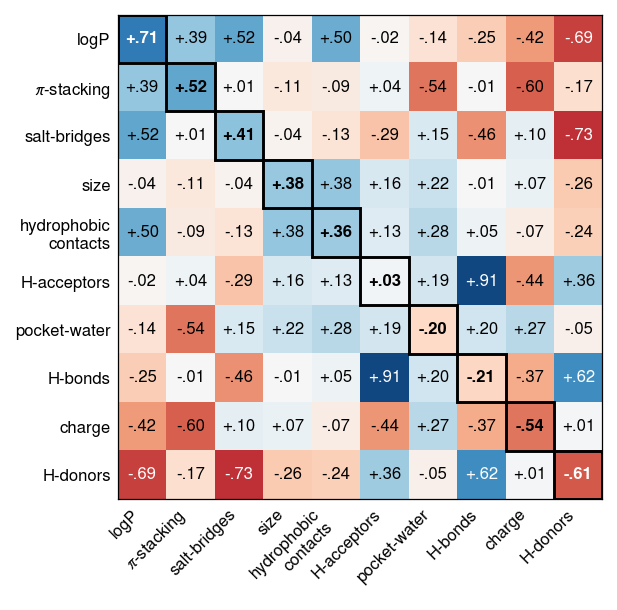

In [ ]:
# Setup figure
fig, axs = plt.subplots(figsize=(4, 4), constrained_layout=True)
ranking_p = ranking_data.drop(columns=["target", "n", 'rho','sar_pi_cation'])
corr = ranking_p.corr().values.copy()
for i, k in enumerate(ranking_p.columns):
    corr[i, i] = pearsonr(ranking_p[k], ranking_data["rho"]).statistic
reorder = np.argsort(np.diag(corr))[::-1]
corr = corr[reorder][:, reorder]
labels = [e.replace("sar_", "") for e in ranking_p.columns[reorder]]
repl = {"logp": "logP", "pi_stacking": r"$\pi$-stacking", "salt": "salt-bridges", "hydrophobic": "hydrophobic\ncontacts",
    "hb_don": "H-donors", "hb_acc": "H-acceptors", "hb": "H-bonds", "water": "pocket-water"
}
for k, rep in repl.items():
    labels[labels.index(k)] = rep
im = axs.imshow(corr, cmap="RdBu", vmin=-1, vmax=1)
axs.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
axs.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        if not np.isnan(corr[i, j]):
            color = 'black' if abs(corr[i, j]) < 0.6 else "white"
            text = f"{corr[i, j]:+.2f}".replace("0.", ".")
            axs.text(j, i, text, ha="center", va="center", fontsize=8, color=color, fontweight="bold" if i == j else "normal")
    axs.add_patch(Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="black", lw=1.4))
axs.tick_params(length=0)
save_figure(fig, "si-ranking-heatmap-full")
plt.show()

protein SEM 0.18, 90th pct 0.41, max 0.65 kcal/mol over 172 ligands
protein lambda stride 1: 0.03 kcal/mol
protein lambda stride 3: 0.04 kcal/mol
protein sampling 0.6: 0.27 kcal/mol
water SEM 0.06, 90th pct 0.19, max 0.75 kcal/mol over 172 ligands
water lambda stride 1: 0.06 kcal/mol
water lambda stride 3: 0.18 kcal/mol
water sampling 0.6: 0.06 kcal/mol


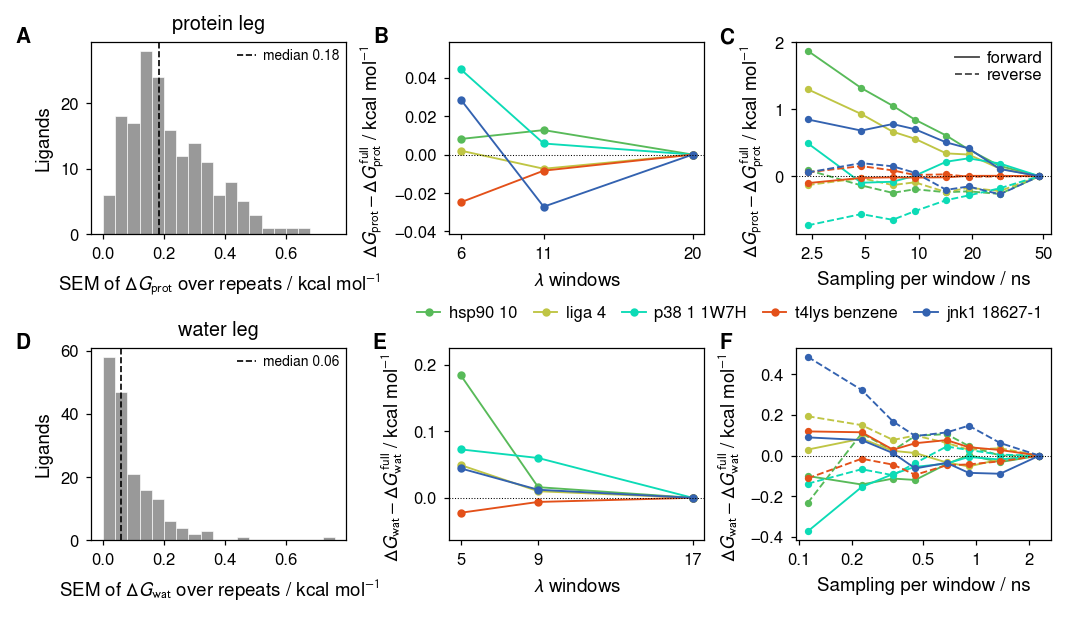

In [9]:
with open("convergence.json") as f:
    convergence = json.load(f)
    del convergence["jak2_1_3E62"]
CONV_SYSTEMS = list(convergence)
RATIOS = sorted(convergence[CONV_SYSTEMS[0]]["water"]["0"], key=float)
STRIDES = sorted(convergence[CONV_SYSTEMS[0]]["water"], key=int)
CONV_LEGS = [
    ("protein", "protein", r"\mathrm{prot}", [2.5, 5, 10, 20, 50]),
    ("water", "waterS", r"\mathrm{wat}", [0.1, 0.2, 0.5, 1.0, 2.0]),
]
SEM_BINS = np.arange(0, 0.8, 0.04)

def conv_leg(system, env, stride, ratio, direction):
    """Decoupling free energy of one leg averaged over r1 and r2, and its sampling time."""
    entry = convergence[system][env][str(stride)][ratio][direction]
    return float(np.mean([entry[k]["dG"] for k in ("r1", "r2")])), entry["r1"][
        "time_ns"
    ]

fig, axs = figure("double", height=4.0, nrows=2, ncols=3)
summary = {}
for row, (env, prefix, label, ticks) in enumerate(CONV_LEGS):
    # panels A and D, repeat to repeat spread of every ligand in the set
    spread = repeat_spread(prefix)
    axs[row, 0].hist(spread, bins=SEM_BINS, color="0.6", edgecolor="white", lw=0.3)
    axs[row, 0].axvline(np.median(spread), color="black", lw=0.8, ls="--",
        label=f"median {np.median(spread):.2f}")
    axs[row, 0].set(xlabel=rf"SEM of $\Delta G_{{{label}}}$ over repeats / kcal mol$^{{-1}}$",
        ylabel="Ligands", title=f"{env} leg")
    axs[row, 0].legend(fontsize="small", handletextpad=0.5)
    # panels B and E, coarsening the lambda schedule
    for i, system in enumerate(CONV_SYSTEMS):
        reference = conv_leg(system, env, 0, "1.00", "forward")[0]
        windows = [convergence[system][env][s]["1.00"]["forward"]["r1"]["n_windows"] for s in STRIDES]
        wreps = [conv_leg(system, env, int(s), "1.00", "forward")[0] - reference for s in STRIDES]
        color = COLORS[data["target"].unique().tolist().index(system.split("_")[0])]
        axs[row, 1].plot(windows,wreps, "-o", color=color, lw=0.9, ms=3, label=system.replace("_", " "))
    axs[row, 1].axhline(0, color="black", lw=0.5, ls=":")
    axs[row, 1].set(xlabel=r"$\lambda$ windows", xticks=windows)
    axs[row, 1].margins(y=0.2)
    axs[row, 1].set_ylabel(rf"$\Delta G_{{{label}}} - \Delta G_{{{label}}}"
        r"^{\mathrm{full}}$ / kcal mol$^{-1}$", y=0.43)
    if row == 0:
        leg = axs[row, 1].legend(labelspacing=0.1, handletextpad=0.5, ncols=5, bbox_to_anchor=(1.1, -0.5), loc="lower center")
        leg.set_in_layout(False)
    # panels C and F, forward and reverse subsampling of every window
    for i, system in enumerate(CONV_SYSTEMS):
        reference = conv_leg(system, env, 0, "1.00", "forward")[0]
        for direction, dashes in (("forward", "-"), ("reverse", "--")):
            points = [conv_leg(system, env, 0, r, direction) for r in RATIOS]
            color = COLORS[data["target"].unique().tolist().index(system.split("_")[0])]
            axs[row, 2].plot([p[1] for p in points], [p[0] - reference for p in points],
                dashes, color=color, lw=0.9, ms=2.5, marker="o")
    axs[row, 2].axhline(0, color="black", lw=0.5, ls=":")
    axs[row, 2].set(xlabel="Sampling per window / ns", xscale="log", xticks=ticks, xticklabels=[f"{t:g}" for t in ticks])
    axs[row, 2].minorticks_off()
    axs[row, 2].set_ylabel(rf"$\Delta G_{{{label}}} - \Delta G_{{{label}}}"
                           r"^{\mathrm{full}}$ / kcal mol$^{-1}$", y=0.43)
    if row == 0:
        axs[row, 2].plot([], [], "-", color="0.3", lw=0.9, label="forward")
        axs[row, 2].plot([], [], "--", color="0.3", lw=0.9, label="reverse")
        axs[row, 2].legend(labelspacing=0.1, handletextpad=0.5)
    # the numbers to quote, per leg
    print(f'{env} SEM {np.median(spread):.2f}, 90th pct {np.quantile(spread, 0.9):.2f}, max {spread.max():.2f} kcal/mol over {len(spread)} ligands')
    print(f'{env} lambda stride 1: {max(abs(conv_leg(s, env, 1, "1.00", "forward")[0] - conv_leg(s, env, 0, "1.00", "forward")[0]) for s in CONV_SYSTEMS):.2f} kcal/mol')
    print(f"{env} lambda stride 3: {max(abs(conv_leg(s, env, 3, '1.00', 'forward')[0] - conv_leg(s, env, 0, '1.00', 'forward')[0]) for s in CONV_SYSTEMS):.2f} kcal/mol")
    print(f"{env} sampling 0.6: {max(abs(conv_leg(s, env, 0, '0.60', 'reverse')[0] - conv_leg(s, env, 0, '1.00', 'forward')[0]) for s in CONV_SYSTEMS):.2f} kcal/mol")
for k, letter in enumerate("ABCDEF"):
    axs[k // 3, k % 3].annotate(letter, xy=(-0.3, 1.08), xycoords="axes fraction",
        ha="left", va="top", fontweight="bold", fontsize=10)
fig.set_constrained_layout_pads(hspace=0.08)
save_figure(fig, "si-dd-convergence")
plt.show()